In [259]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings("ignore")


In [211]:
df = pd.read_excel('data/serie_cafe_cepea_att_mar_26.xlsx')
df.rename(columns = {
    'Data': 'date',
    'À vista R$': 'price_brl',
    'À vista US$': 'price_usd'
}, inplace = True)
df["log_price_brl"] = np.log(df["price_brl"])

In [212]:
series = df["log_price_brl"].copy()
series.index = df['date']
series = series.sort_index()


In [213]:
start_train_idx = series.index.searchsorted("2018-01-01")

print("Índice inicial:", start_train_idx)
print("Data inicial:", series.index[start_train_idx])


Índice inicial: 256
Data inicial: 2018-01-01 00:00:00


In [294]:
def create_dataset(df, horizon):

    data = df.copy()

    for lag in [1,2,3,6,12]:
        data[f"log_price_brl_lag_{lag}"] = data["log_price_brl"].shift(lag)

    # data['rolling_mean_3'] = data['log_price_brl'].rolling(window=3).mean()
    # data['rolling_mean_6'] = data['log_price_brl'].rolling(window=6).mean()
    # data['std_col'] = data['log_price_brl'].rolling(window=3).std()

    # data['Month'] = data['date'].dt.month
    # data['Year'] = data['date'].dt.year

    data['log_price_n'] = data['log_price_brl']

    feature_cols = data.columns.drop([
        "date",
        "price_brl",
        "price_usd",
        "log_price_brl"
    ])

    X = data[feature_cols]
    y = data["log_price_brl"].shift(-horizon)

    data = pd.concat([X, y], axis=1).dropna()

    X = data[feature_cols]
    y = data["log_price_brl"]

    return X, y

In [295]:
def walk_forward_forecast(
    df,
    series,
    start_train_idx,
    horizon
):
    """
    series: pandas Series (log-price mensal)
    model_func: função que recebe série de treino e horizonte e retorna previsão
    start_train_idx: índice inicial do walk-forward
    horizon: horizonte de previsão (int)
    """
    
    forecasts = []
    actuals = []
    dates = []


    for t in range(start_train_idx, len(series) - horizon):

        train_df = df.iloc[:t].copy()

        X_train, y_train = create_dataset(train_df, horizon)

        model = DecisionTreeRegressor(random_state=42)
        model.fit(X_train, y_train)


        pred_df = df.iloc[:t + 1].copy()
        X_all, _ = create_dataset(pred_df, horizon)
        X_pred = X_all.iloc[[-1]]
        y_hat = model.predict(X_pred)[0]
        actual = _.iloc[-1]


        forecasts.append(y_hat)
        actuals.append(actual)
        dates.append(df.index[t + horizon -1])

    return pd.DataFrame({
        "date": dates,
        "y_true": actuals,
        "y_pred": forecasts
    }).set_index("date")


def forecast_metrics(df):

    y_true = np.exp(df.y_true)
    y_pred = np.exp(df.y_pred)

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }



In [296]:
horizons = [1, 3, 6]

tree_results = {}

for h in horizons:
    df_pred = walk_forward_forecast(
        df=df,
        series=series,
        start_train_idx=start_train_idx,
        horizon=h
    )
    tree_results[h] = df_pred

In [297]:
for h, df_pred in tree_results.items():
    print(f"Horizonte {h} mês(es):")
    print(forecast_metrics(df_pred))
    print()


Horizonte 1 mês(es):
{'RMSE': np.float64(134.02931096957712), 'MAE': np.float64(86.33928571428568), 'MAPE': np.float64(7.869105102737074)}

Horizonte 3 mês(es):
{'RMSE': np.float64(201.70682239587646), 'MAE': np.float64(114.0817708333333), 'MAPE': np.float64(9.82051924560368)}

Horizonte 6 mês(es):
{'RMSE': np.float64(167.50369002836405), 'MAE': np.float64(108.64419354838704), 'MAPE': np.float64(11.269394568957145)}



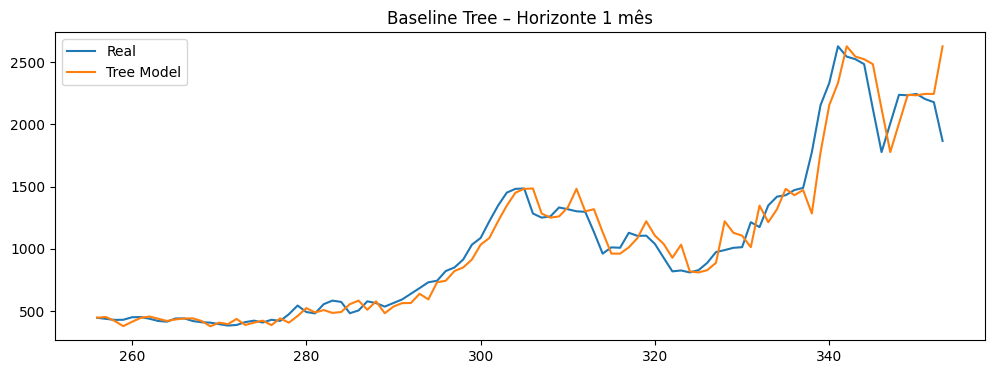

In [257]:
import matplotlib.pyplot as plt

df_plot = tree_results[1]

y_true = np.exp(df_plot.y_true)
y_pred = np.exp(df_plot.y_pred)

plt.figure(figsize=(12,4))
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Tree Model")
plt.legend()
plt.title("Baseline Tree – Horizonte 1 mês")
plt.show()


In [299]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def walk_forward_forecast(
    df,
    series,
    start_train_idx,
    horizon,
    model_class
):

    forecasts = []
    actuals = []
    dates = []

    for t in range(start_train_idx, len(series) - horizon):

        train_df = df.iloc[:t].copy()

        X_train, y_train = create_dataset(train_df, horizon)

        model = model_class()
        model.fit(X_train, y_train)

        pred_df = df.iloc[:t + 1].copy()
        X_all, y_all = create_dataset(pred_df, horizon)

        X_pred = X_all.iloc[[-1]]

        y_hat = model.predict(X_pred)[0]
        actual = y_all.iloc[-1]

        forecasts.append(y_hat)
        actuals.append(actual)
        dates.append(df.index[t + horizon - 1])

    return pd.DataFrame({
        "date": dates,
        "y_true": actuals,
        "y_pred": forecasts
    }).set_index("date")

models = {
    "DecisionTree": lambda: DecisionTreeRegressor(random_state=42),
    "RandomForest": lambda: RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": lambda: XGBRegressor(
         n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

horizons = [1, 3, 6]

all_results = {}

for model_name, model_func in models.items():

    model_results = {}

    for h in horizons:

        df_pred = walk_forward_forecast(
            df=df,
            series=series,
            start_train_idx=start_train_idx,
            horizon=h,
            model_class=model_func
        )

        model_results[h] = df_pred

    all_results[model_name] = model_results

metrics = {}

for model_name, horizons_dict in all_results.items():

    metrics[model_name] = {}

    for h, df_pred in horizons_dict.items():

        metrics[model_name][h] = forecast_metrics(df_pred)

metrics_df = pd.DataFrame(metrics).T
metrics_df

,1,3,6
DecisionTree,"{'RMSE': 134.02931096957712, 'MAE': 86.3392857...","{'RMSE': 201.70682239587646, 'MAE': 114.081770...","{'RMSE': 167.50369002836405, 'MAE': 108.644193..."
RandomForest,"{'RMSE': 145.54160529487746, 'MAE': 90.9598025...","{'RMSE': 198.084698016846, 'MAE': 121.88274472...","{'RMSE': 237.89166520802152, 'MAE': 144.888554..."
XGBoost,"{'RMSE': 145.56444750164533, 'MAE': 88.9614395...","{'RMSE': 191.5808729806469, 'MAE': 120.7567832...","{'RMSE': 256.9050701721006, 'MAE': 155.9633732..."
